# List 1

**Introduction to tools for data analysis and classification model building**

In the following tasks you will use the *Adult* dataset available in the `sklearn` library.

In [1]:
from sklearn.datasets import fetch_openml
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame

In [2]:
display(df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In this version of the dataset, the target variable is the `class` column.
While completing the tasks, you should use the following libraries: `pandas`, `matplotlib`, `sklearn`, and `torch`.

---

## 1. EDA — pandas

The goal of this section is to become familiar with basic operations on a `DataFrame`.

### Task 1 — Basic information

1. Print the number of rows and columns in the dataset.
2. Print the names of all columns.
3. Check the number of missing values in each column.
4. Display descriptive statistics for numerical columns using the appropriate `pandas` method.

In [3]:
# 1. Number of rows and columns
display(df.shape) # (rows, columns)

# 2. Column names
display(df.columns.tolist())

# 3. Number of missing values in each column
display(df.isnull().sum(axis=0)) # .sum() also work

# 4. Basic statistics for numerical columns
display(df.describe())

(48842, 15)

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'class']

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### Task 2 — Category counts

1. Compute the number of observations in each category of the `education` variable.
2. Sort the result in descending order by count.
3. Print the five most frequent categories.

In [4]:
# 1. Number of observations in each category of the 'education' column
display(df['education'].value_counts())

number_of_observations = df['education'].value_counts()

# 2. Results in descedning order by count

# display(df['education'].value_counts(ascending=False)) # Also works

number_of_observations_descending = number_of_observations.sort_values(ascending=False)

display(number_of_observations_descending)

# 3. Five most frequent categories

# display(number_of_observations_descending.head(5)) # Also works
# display(number_of_observations.nlargest(5)) # Also works

most_frequent_categories = number_of_observations_descending[0:5]

display(most_frequent_categories)

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
Name: count, dtype: int64

### Task 3 — Grouping and aggregation

For each category of the `education` variable, compute:

* the mean value of `hours-per-week`,
* the mean value of `capital-gain`,
* the percentage of observations belonging to the `>50K` class (based on the `class` column).

Use the `groupby()` and `agg()` methods.

In [5]:
results = df.groupby('education').agg({
    'hours-per-week': 'mean',
    'capital-gain': 'mean',
    'class': lambda x: (x == '>50K').mean() * 100
}).rename(columns={
    'hours-per-week': 'average_hours_per_week',
    'capital-gain': 'average_capital_gain',
    'class': 'percentage_earning_over_>50K'
})

display(results)

,average_hours_per_week,average_capital_gain,percentage_earning_over_>50K
education,,,
10th,36.986321,323.049676,6.263499
11th,33.952539,203.739514,5.077263
12th,35.374429,208.579909,7.305936
1st-4th,38.761134,123.591093,3.238866
5th-6th,38.923379,360.365422,5.304519
7th-8th,39.003141,242.626178,6.492147
9th,38.359788,313.398148,5.423280
Assoc-acdm,40.809494,636.951905,25.796377
Assoc-voc,41.658418,778.602135,25.327511


### Task 4 — Filtering data

1. Select observations for which `capital-gain > 0`.
2. Compute the mean `hours-per-week` for this group.
3. Compute the mean `hours-per-week` for observations with `capital-gain == 0`.

In [6]:
results = df.groupby(df['capital-gain'] > 0).agg({'hours-per-week': 'mean'}).rename(index={False: 'capital-gain == 0', True: 'capital-gain > 0'})

display(results)

,hours-per-week
capital-gain,
capital-gain == 0,40.142879
capital-gain > 0,43.526146


### Task 5 — Creating a new column

1. Create a new column called `hours_bucket` by dividing `hours-per-week` into intervals of 10 hours using `pd.cut`.
2. Compute the number of observations in each interval.
3. Create a pivot table in which:

   * the index is `hours_bucket`,
   * the columns correspond to `class`,
   * the values represent the number of observations.

In [7]:
import numpy as np
import pandas as pd

mini = df['hours-per-week'].min() # 1
maxi = df['hours-per-week'].max() # 99

bins = np.arange(0, 101, 10) 
df['hours_bucket'] = pd.cut(df['hours-per-week'], bins=bins)

counts = df['hours_bucket'].value_counts().sort_index()
display(counts)

pivot_df = df.pivot_table(
    index='hours_bucket', 
    columns='class', 
    aggfunc='size',       # Zlicza liczbę wierszy (obserwacji) w danej grupie
    fill_value=0          # Wypełnia zera tam, gdzie nie ma żadnych obserwacji
)

display(pivot_df)

hours_bucket
(0, 10]       1125
(10, 20]      3328
(20, 30]      3398
(30, 40]     26639
(40, 50]      8917
(50, 60]      3759
(60, 70]       902
(70, 80]       456
(80, 90]       147
(90, 100]      171
Name: count, dtype: int64

class,<=50K,>50K
hours_bucket,,
"(0, 10]",1020,105
"(10, 20]",3132,196
"(20, 30]",3173,225
"(30, 40]",21220,5419
"(40, 50]",5398,3519
"(50, 60]",2135,1624
"(60, 70]",570,332
"(70, 80]",289,167
"(80, 90]",95,52


## 2. Visualization — matplotlib

Each plot must include a title, axis labels, and a legend (if applicable).

---

### Plot 1 — Histogram

Create a histogram of the `hours-per-week` variable.
Choose the number of bins in a reasonable way.

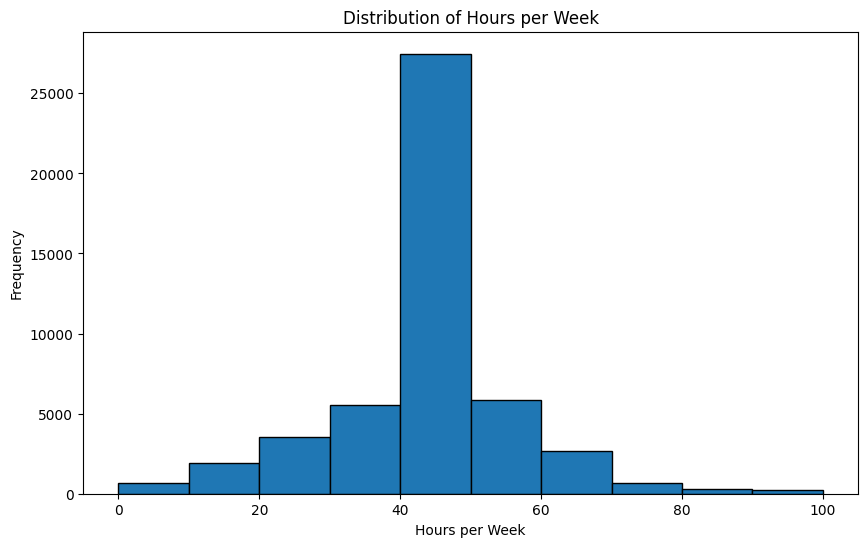

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df['hours-per-week'], bins=bins, edgecolor='black')

plt.title('Distribution of Hours per Week')
plt.xlabel('Hours per Week')
plt.ylabel('Frequency')

plt.show()

### Plot 2 — Histogram comparison

On a single figure, plot two histograms of `hours-per-week`:

* one for the `<=50K` class,
* one for the `>50K` class.

The histograms should be semi-transparent (set the `alpha` parameter).

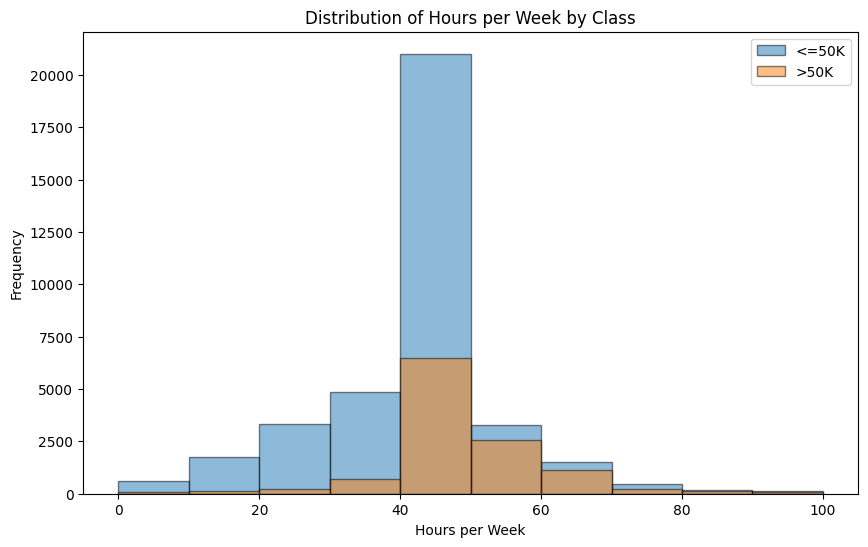

In [9]:
plt.figure(figsize=(10, 6))

hle = df[df['class'] == '<=50K']['hours-per-week']
hg = df[df['class'] == '>50K']['hours-per-week']

plt.hist(hle, bins=bins, edgecolor='black', alpha=0.5, label='<=50K')
plt.hist(hg, bins=bins, edgecolor='black', alpha=0.5, label='>50K')

plt.title('Distribution of Hours per Week by Class')
plt.xlabel('Hours per Week')
plt.ylabel('Frequency')
plt.legend()

plt.show()

### Plot 3 — Bar chart

Create a bar chart showing the number of observations for each category of the `education` variable.

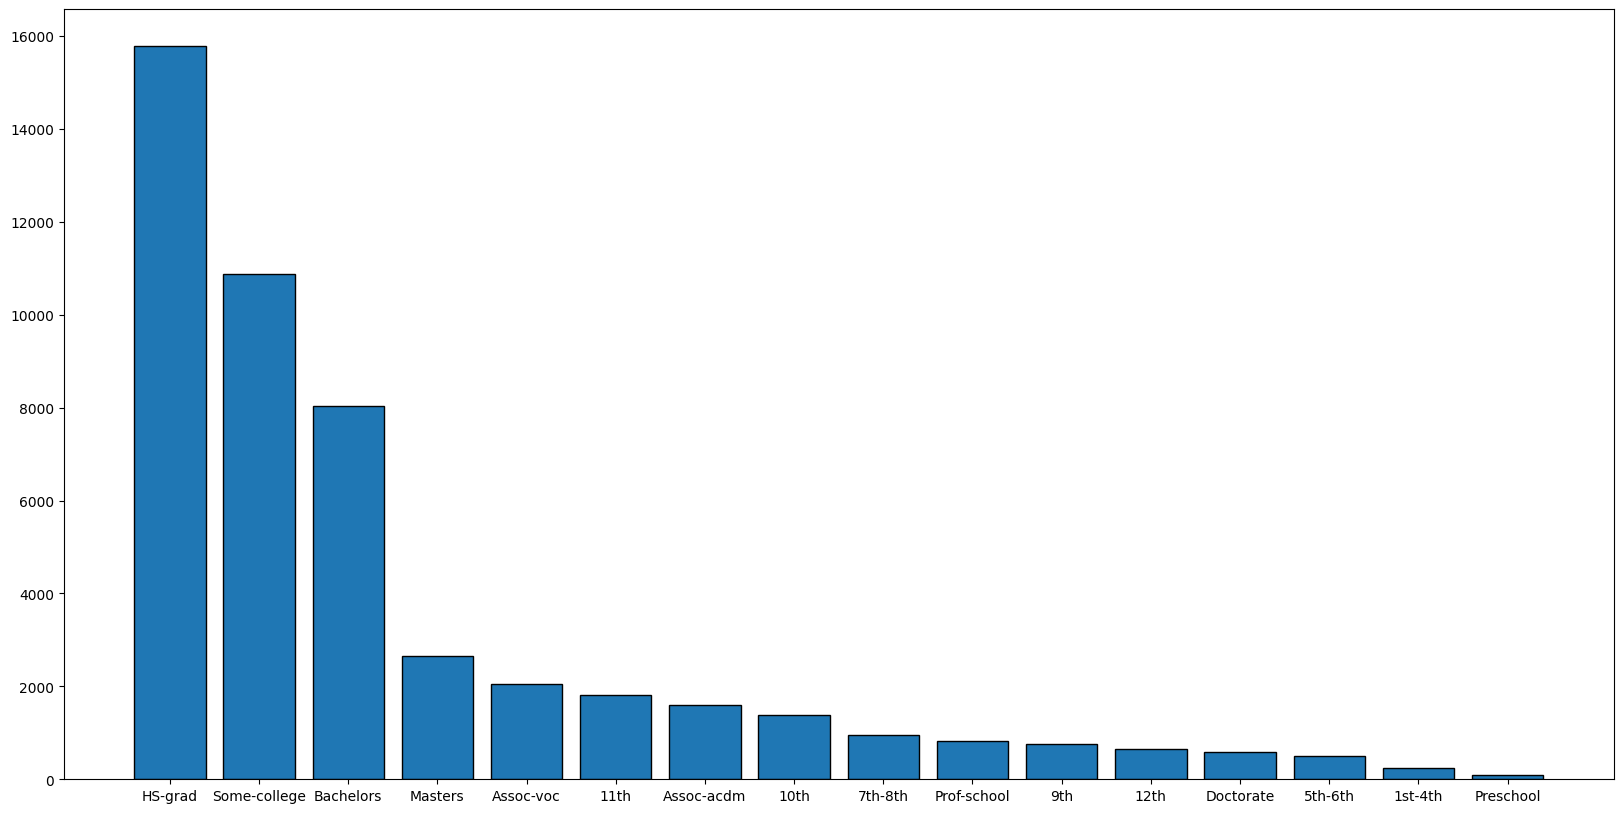

In [10]:
education_counts = df['education'].value_counts()

plt.figure(figsize=(20, 10))

plt.bar(education_counts.index, education_counts.values, edgecolor='black')

plt.show()

### Plot 4 — Scatter plot

Create a scatter plot where:

* the X-axis represents `capital-gain`,
* the Y-axis represents `hours-per-week`.

Set `alpha < 0.3`.

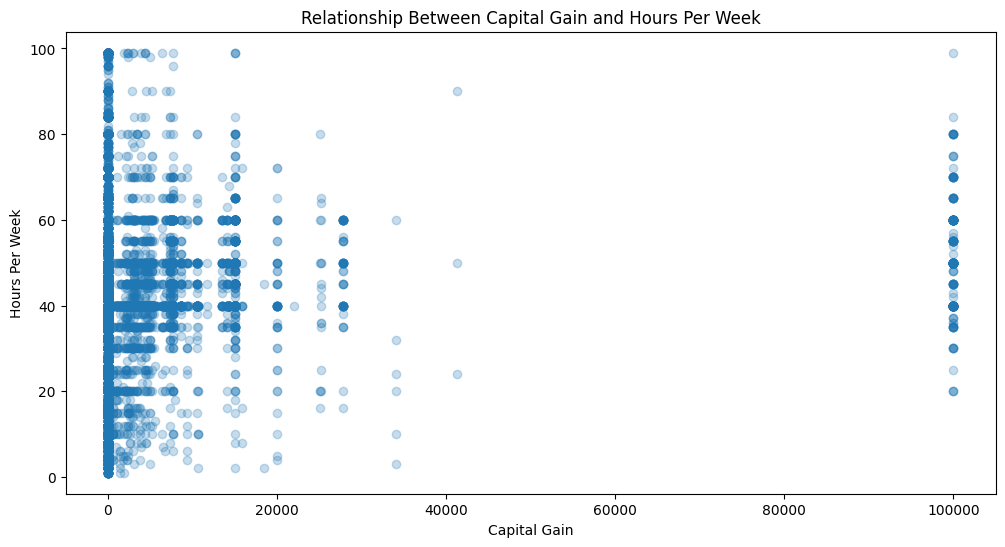

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(df['capital-gain'], df['hours-per-week'], alpha=0.25)

plt.title('Relationship Between Capital Gain and Hours Per Week')
plt.xlabel('Capital Gain')
plt.ylabel('Hours Per Week')

plt.show()

### Plot 5 — Logarithmic scale

Create a histogram of `capital-gain`.
Set the X-axis to a logarithmic scale.

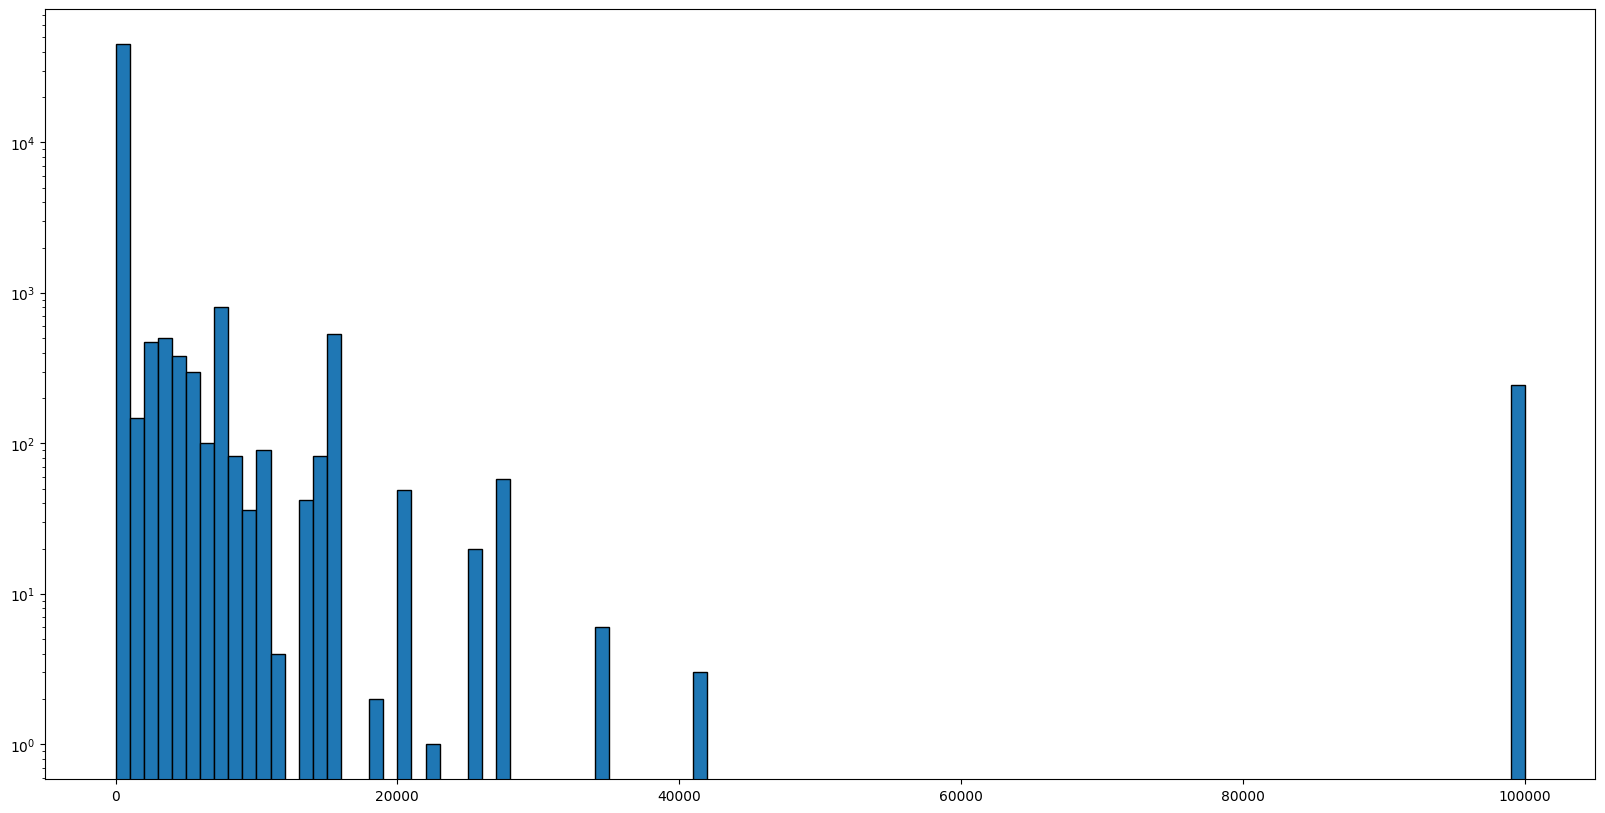

In [12]:
plt.figure(figsize=(20, 10))

plt.hist(df['capital-gain'], bins=100, edgecolor='black', log=True)

plt.show()

## 3. Data splitting — sklearn

Before splitting the data, separate:

* the feature matrix `X` (all columns except `class`),
* the target vector `y` (the `class` column).

In [13]:
X = df.drop(columns=['class'])
y = df['class']

### Task 1 — Train/validation/test split

1. Split the data into:

   * training set (60%),
   * validation set (20%),
   * test set (20%).

2. Use `train_test_split` with the `stratify=y` parameter to preserve class proportions.

3. Print the size of each split.

4. Print the class proportions in each split.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, 
    test_size=0.4, 
    random_state=2137, 
    stratify=y         
)

X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, 
    test_size=0.5, 
    random_state=2137, 
    stratify=y_rest    
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Training set size: 29305
Validation set size: 9768
Test set size: 9769


### Task 2 — Baseline model

The baseline model is a classifier that does not use input features and always predicts the majority class from the training set.

1. Determine the majority class in the training set.
2. Build a classifier that predicts this class for all test observations.
3. Compute the following metrics on the test set:

   * Accuracy,
   * Precision,
   * Recall,
   * F1.

You may implement this manually or use `DummyClassifier(strategy="most_frequent")`.

In [15]:
import numpy as np

majority_class = y_train.value_counts().idxmax()
print(f"Majority class in the training set: {majority_class}")

y_pred_manual = np.full(len(y_test), majority_class)

TP = ((y_pred_manual == majority_class) & (y_test == majority_class)).sum()

FP = ((y_pred_manual == majority_class) & (y_test != majority_class)).sum()

FN = ((y_pred_manual != majority_class) & (y_test == majority_class)).sum()

accuracy_manual = (y_pred_manual == y_test).mean()

precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall_manual = TP / (TP + FN) if (TP + FN) > 0 else 0.0

if (precision_manual + recall_manual) > 0:
    f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
else:
    f1_manual = 0.0

print(f"Manual baseline accuracy: {accuracy_manual:.4f}")
print(f"Manual baseline precision: {precision_manual:.4f}")
print(f"Manual baseline recall: {recall_manual:.4f}")
print(f"Manual baseline F1-score: {f1_manual:.4f}")

Majority class in the training set: <=50K
Manual baseline accuracy: 0.7607
Manual baseline precision: 0.7607
Manual baseline recall: 1.0000
Manual baseline F1-score: 0.8641


## 4. Pipeline — sklearn

### Task 1 — Preprocessing

1. Split the columns into numerical and categorical features.

2. Build a `ColumnTransformer` where:

   * numerical columns are processed with:

     * `SimpleImputer(strategy="median")`,
     * `StandardScaler`,
   * categorical columns are processed with:

     * `SimpleImputer(strategy="most_frequent")`,
     * `OneHotEncoder(handle_unknown="ignore")`.

3. Fit the preprocessing pipeline on the training set and check the shape of the transformed feature matrix.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

display(X_train.dtypes)

numerical_colums = X_train.select_dtypes(include=['int64']).columns.tolist()
caterofical_columns = X_train.select_dtypes(include=['category']).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_colums),
        ('cat', categorical_pipeline, caterofical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

print(f"X_train: {X_train.shape}")
print(f"Processed X_train: {X_train_processed.shape}")

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
hours_bucket      category
dtype: object

X_train: (29305, 15)
Processed X_train: (29305, 115)


### Task 2 — Logistic regression

1. Build a `Pipeline` consisting of:

   * preprocessing,
   * `LogisticRegression(max_iter=1000)`.

2. Train the model on the training set.

3. Compute the following metrics on the validation set:

   * Accuracy,
   * F1,

In [17]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, f1_score

model = LogisticRegression(max_iter=1000, random_state=2137)

training_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

training_pipeline.fit(X_train, y_train)

y_val_pred = training_pipeline.predict(X_val)

acc_val = accuracy_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred, pos_label='>50K') 

print("\n--- Logistic Regression Metrics (Validation Set) ---")
print(f"Accuracy: {acc_val:.4f}")
print(f"F1-score: {f1_val:.4f}")


--- Logistic Regression Metrics (Validation Set) ---
Accuracy: 0.8500
F1-score: 0.6549


## 5. GridSearch

### Task — Hyperparameter tuning for logistic regression

1. Define the parameter grid:

   * `C`: [0.01, 0.1, 1, 10].

2. Use `GridSearchCV` with:

   * `scoring="f1"`,
   * `cv=5`.

3. Fit the model on the training set.

4. Print the best parameters (`best_params_`) and the best cross-validation score (`best_score_`).

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer


custom_f1_scorer = make_scorer(f1_score, pos_label='>50K')

search = GridSearchCV(
    estimator=training_pipeline,
    param_grid={
        "classifier__C": [0.01, 0.1, 1, 10]
    },
    scoring=custom_f1_scorer,
    cv=5,
)

search.fit(X_train, y_train)

print(f"Best hyperparameters: {search.best_params_}")
print(f"Best cross-validation F1-score: {search.best_score_:.4f}")

Best hyperparameters: {'classifier__C': 1}
Best cross-validation F1-score: 0.6642


## 6. MLP — PyTorch

In this section, use the data after preprocessing (the same transformations as in `sklearn`).

1. Fit the preprocessing pipeline on the training set.
2. Transform the training, validation, and test sets.
3. Convert the resulting matrices to `float32` tensors.
4. Encode the labels as 0 and 1.

---

### Task 1 — Network architecture

Build an MLP with the following structure:

* Input layer: number of neurons equal to the number of features after preprocessing.
* Hidden layer 1: `Linear(in_features, 128)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 2: `Linear(128, 64)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 3: `Linear(64, 32)` → `ReLU` → `Dropout(p=0.3)`.
* Output layer: `Linear(32, 1)`.

Do not apply a sigmoid activation inside the model.
Use `BCEWithLogitsLoss` as the loss function.

In [19]:
import torch
import torch.nn as nn

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_train_tensor = torch.tensor(X_train_processed.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor((y_train == '>50K').astype(int).values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_processed.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor((y_val == '>50K').astype(int).values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_processed.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor((y_test == '>50K').astype(int).values, dtype=torch.float32)

model = nn.Sequential(
    # Hidden layer 1
    nn.Linear(X_train_tensor.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    # Hidden layer 2
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    # Hidden layer 3
    nn.Linear(64, 32),
    nn.ReLU(), 
    nn.Dropout(p=0.3),

    # Output layer
    nn.Linear(32, 1),
)

criterion = nn.BCEWithLogitsLoss()

print(model)

Sequential(
  (0): Linear(in_features=115, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=32, out_features=1, bias=True)
)


### Task 2 — Training

1. Use the `Adam` optimizer.

2. Apply a `StepLR` scheduler with `step_size=5` and `gamma=0.5`.

3. Implement early stopping with `patience=5`, monitoring the validation loss.

4. During each epoch, record:

   * training loss,
   * validation loss,
   * validation accuracy.

5. After training, plot training loss and validation loss as a function of epoch number.

Epoch 001 | Train Loss: 0.4739 | Val Loss: 0.4558 | Val Acc: 0.7626
Epoch 002 | Train Loss: 0.4634 | Val Loss: 0.4453 | Val Acc: 0.7639
Epoch 003 | Train Loss: 0.4536 | Val Loss: 0.4354 | Val Acc: 0.7661
Epoch 004 | Train Loss: 0.4436 | Val Loss: 0.4262 | Val Acc: 0.7701
Epoch 005 | Train Loss: 0.4342 | Val Loss: 0.4175 | Val Acc: 0.7744
Epoch 006 | Train Loss: 0.4262 | Val Loss: 0.4133 | Val Acc: 0.7776
Epoch 007 | Train Loss: 0.4233 | Val Loss: 0.4093 | Val Acc: 0.7820
Epoch 008 | Train Loss: 0.4186 | Val Loss: 0.4054 | Val Acc: 0.7872
Epoch 009 | Train Loss: 0.4144 | Val Loss: 0.4016 | Val Acc: 0.7926
Epoch 010 | Train Loss: 0.4108 | Val Loss: 0.3980 | Val Acc: 0.7986
Epoch 011 | Train Loss: 0.4066 | Val Loss: 0.3962 | Val Acc: 0.8023
Epoch 012 | Train Loss: 0.4063 | Val Loss: 0.3945 | Val Acc: 0.8056
Epoch 013 | Train Loss: 0.4035 | Val Loss: 0.3928 | Val Acc: 0.8080
Epoch 014 | Train Loss: 0.4015 | Val Loss: 0.3911 | Val Acc: 0.8101
Epoch 015 | Train Loss: 0.3998 | Val Loss: 0.389

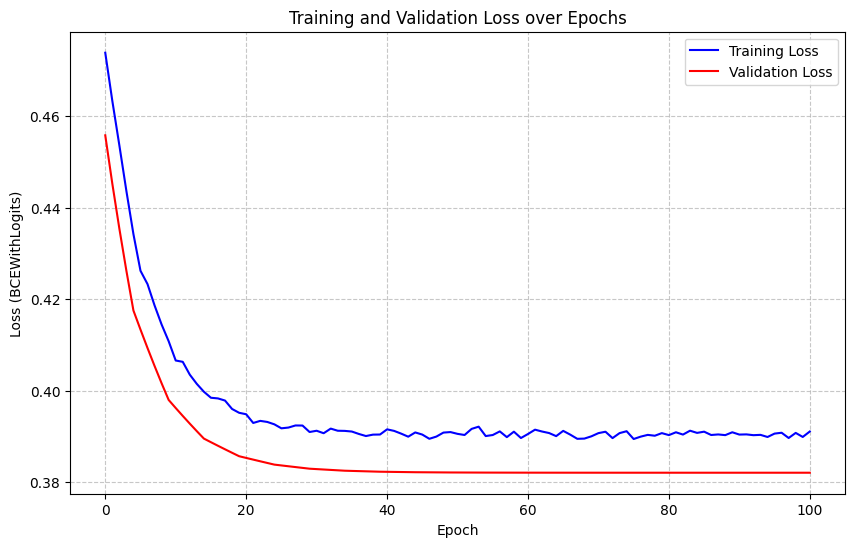

In [33]:
from torch.optim.lr_scheduler import StepLR

import copy

optimizer = torch.optim.Adam(model.parameters())

scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

train_losses = []
val_losses = []
val_accuracies = []

num_epochs = 1000

patience = 5
patience_counter = 0
best_val_loss = float('inf')
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor).squeeze()
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())

        val_predictions = (torch.sigmoid(val_outputs) > 0.5).float()
        val_accuracy = (val_predictions == y_val_tensor).float().mean().item()
        val_accuracies.append(val_accuracy)

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
                
        print(f"Epoch {epoch+1:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_accuracy:.4f}")

        scheduler.step()

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break


model.load_state_dict(best_model_state)

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCEWithLogits)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Task 3 — Evaluation

On the test set, compute:

* Accuracy,
* F1.

In [34]:
from sklearn.metrics import f1_score, accuracy_score

model.load_state_dict(best_model_state)

model.eval()
with torch.no_grad():
    best_outputs = model(X_val_tensor).squeeze()
    best_predictions = (torch.sigmoid(best_outputs) > 0.5).float()

y_true_np = y_val_tensor.numpy()
y_pred_np = best_predictions.numpy()

f1 = f1_score(y_true_np, y_pred_np, pos_label=1.0)
accuracy = accuracy_score(y_true_np, y_pred_np)    

print(f"F1 Score (Best Model): {f1:.4f}")
print(f"Accuracy (Best Model): {accuracy:.4f}")

F1 Score (Best Model): 0.4686
Accuracy (Best Model): 0.8200


## 7. Error analysis

1. Compute predicted probabilities for the positive class on the test set.
2. Identify:

   * 50 false positive cases with the highest predicted probability,
   * 50 false negative cases with the highest predicted probability.

In [36]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).squeeze().numpy()

y_test_true = y_test_tensor.squeeze().numpy()

results_df = pd.DataFrame({
    'true_label': y_test_true,
    'predicted_prob': test_probs
})

display(results_df.head())

,true_label,predicted_prob
0,0.0,0.210714
1,0.0,0.094971
2,0.0,0.031054
3,0.0,0.262192
4,1.0,0.615861


## 8. Final report

In the final report, answer the following questions:

1. Which model achieved the highest F1 score?
2. Do the learning curves indicate a stable training process?
3. Did overfitting occur in the MLP model (compare training and validation loss)?

1. F1 score for LogReg: 0.6642 and for MLP only: 0.4686

2. Yes, learing curves for MLP are stable, and from 20th epoch.

3. Hard to say, curves stabalize near 20th epoch and don't go down much anymore, so it doesn't look like "Training loss going to zero and validation still high"